# Institutional VIX Prediction Framework — Version auditée et corrigée

Pipeline complet de prédiction directionnelle du VIX à horizon t+5 : acquisition de données multi-actifs, feature engineering, détection de régimes (GMM), sélection de features, modèles Deep Learning (LSTM, TCN, Transformer, CNN-LSTM, Transformer-LSTM), explicabilité SHAP, backtest, gestion du risque et validation walk-forward.

**Principales corrections apportées lors de l'audit :**
- Dataset final vide (0 lignes) corrigé : tickers invalides retirés et `dropna()` sécurisé (il supprimait toutes les lignes à cause d'une seule colonne 100% vide).
- Faute de frappe `FRED_DICT` / `fred_dict` corrigée (le téléchargement FRED échouait silencieusement).
- Ordre des cellules remis dans le sens logique d'exécution (les modèles et l'évaluation étaient définis après leur utilisation).
- Fonction `evaluate_model` manquante : ajoutée (AUC-ROC, MCC, classification report, matrice de confusion, courbes ROC/PR).
- Variables incohérentes unifiées : un seul `df_raw`, un seul `selected_features`, une seule classe `VIXDataset`.
- Cible `target_5d` calculée une seule fois par alignement d'index (l'ancienne version la recalculait par position, source de désalignement).
- Bug `target_dir` (colonne inexistante) corrigé en `target_5d`.
- Fuite de normalisation corrigée : val/test utilisent désormais le scaler entraîné sur le train (au lieu de refitter leur propre scaler).
- AUC codé en dur (0.5741) remplacé par un calcul réel.
- Boucles d'entraînement dupliquées fusionnées en une seule fonction `train_model` générique.
- Ajout d'une cellule de configuration centrale (seed, device, hyperparamètres) pour la reproductibilité.

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, roc_curve, matthews_corrcoef, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Configuration centrale (reproductibilite + hyperparametres globaux)
# ------------------------------------------------------------------
# "Plus de donnees" : start_date recule de 2024-01-01 a 2012-01-01. Plus T
# (le nombre de jours dans l'historique) est grand, plus les estimations en
# aval sont statistiquement stables : le GMM (section 2) a besoin d'assez
# d'observations par regime pour estimer moyenne et covariance, et le score
# d'information mutuelle (section 3) a une variance qui decroit en 1/sqrt(T).
# Les tickers cotes trop recemment (IBIT, ETHA en 2024) sont exclus de
# l'univers (BAD_TICKERS) car ils empecheraient sinon le seuil de couverture
# de colonnes plus bas d'accepter les annees anterieures a leur cotation.
CONFIG = {
    'seed': 42,
    'start_date': '2012-01-01',
    'lookback': 21,       # jours de bourse en entree des modeles sequentiels (LSTM/TCN/Transformer)
    'horizon': 5,         # horizon de prediction : direction du VIX dans 5 jours de bourse
    'top_n_initial': 15,  # nb de features de base gardees avant expansion non-lineaire (section 4)
    'top_n_final': 35,    # nb de features (base + complexes) gardees pour la modelisation finale
    # Split chronologique (pas aleatoire), defini UNE SEULE FOIS ici, pour eviter
    # toute fuite d'info du futur vers le passe pendant l'entrainement.
    'train_end':  '2025-12-31',
    'val_start':  '2026-01-01',
    'val_end':    '2026-03-31',
    'test_start': '2026-04-01',
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilise : {device}")

Device utilise : cpu


In [36]:
# ------------------------------------------------------------------
# Univers d'actifs et dictionnaires de renommage
# ------------------------------------------------------------------
BAD_TICKERS = {
    "XXIV", "TVIX", "ZIV", "^MIB", "CELG", "AET", "HES", "GPS", "JWN", "DFS",
    "SPX", "EON", "EDF", "RWE", "SZR", "ICN", "CEIX", "MXEA", "SQ", "SHELL", "K",
    # Tickers confirmes invalides/delistes par yfinance lors de l'audit
    # (cause racine du bug "0 lignes" : une colonne 100% NaN fait tout supprimer par dropna())
    "CBOT_W", "LVRK", "L3HARRIS", "TBP",
    # "Plus de donnees" (etendue jusqu'a 2012) : IBIT et ETHA (ETF crypto au
    # comptant cotes en 2024) sont exclus ici plutot que de laisser leur absence
    # avant cotation tronquer tout le dataset via le seuil de couverture de
    # colonnes (voir build_institutional_dataset, min_valid).
    "IBIT", "ETHA",
}

# Univers Yahoo Finance : indices, volatilite (VIX, VVIX = volatilite de la
# volatilite implicite du VIX, utilisee par le GMM en section 2 pour un
# regime bivarie), matieres premieres, taux, actions sectorielles/geo. VVIX
# a ete ajoute ici : son absence dans la version precedente degradait le GMM
# a une seule dimension (VIX) alors que le code visait un espace 2D.
YF_TICKERS_RAW = """
^GSPC ^IXIC ^DJI ^RUT ^VIX ^VXN ^OVX ^GVZ ^EVZ ^VVIX
^FTSE ^N225 ^HSI ^GDAXI ^FCHI ^STOXX50E
SPY QQQ TLT GLD USO UUP FXE FXY HYG LQD
AAPL MSFT GOOG AMZN NVDA TSLA JPM JNJ V MA PG UNH HD KO PEP T SMFG DIS XOM CVX BAC WMT VZ CSCO ORCL CRM AMD NFLX ADBE INTC CMCSA PFE ABT LLY DHR COST CMG SBUX MCD ACN PYPL QCOM TXN BA GE BABA
^BVSP ^AXJO ^AORD ^IBEX VXX UVXY VIXY SVXY VXZ VIXM XLK XLF XLE XLV XLU XLP XLI XLY XLRE
XLB XLC GOOGL META AVGO ASML WFC GS BLK SCHW MS COF BAX AXP EQR PLD AMT EQIX CCI PSA ABBV
MRK BMY AMGN GILD BNTX MRNA CRSP VRTX ILMN DXCM TDOC CI HUM RTX LMT NOC GD CAT DE ITT
PAYX CTAS MMM HON ETN EMR OTIS JCI PTC SMCI COP SLB EOG MPC PSX VLO PM MO BTI BP TTE
ENB MET ADM MKC SJM CPB GIS MDLZ NSRGY TAP BDX CLX CL UL YUM QSR DPZ BLMN NWL RRR
DASH LYFT UBER TGT M LOW ROST BBY NEE DUK SO AEP EXC SRE ES XEL PPL TMUS CHTR VOD TM LOGI
NET DDOG SLV UNG DBC DBA GDX GDXJ PDBC CORN SOYB IEF SHY SHV BIL AGG BND JNK VCIT
VCSH EMB MBB TIP BNDX HYLD PFFA EWJ EWG EWU EWA EWH EWL EWP EWI EWQ EWT EWY EWZ EWC EWS
EWM FXI MCHI IEMG EEM VEA INDA EPI ASHR TUR EIDO EPOL EZA GXG EGRX FXB FXA FXC FXF CEW
CYB BZF FXD FXN GBTC IBIT COIN MSTR BITO ETHA MARA RIOT CLSK CIFR CORZ IWM IVV VTI VOO VV
VTV VUG VB SCHD VIG HDV NOBL DGRO QUAL VLUE VYMI JEPI XYLD QYLD RYLD ARKK XBI SOXX IBB
IYT XHB KRE KBE ITA XOP OIH IYM PCAR DAL AAL UAL LUV ICLN TAN MTUM USMV SPLV RSP EUSA
EEMV VNQ IYR REM SPG AVB COLD DLR REXR HII LDOS EBAY MELI SHOP SE PDD JD VIPS
UPST RBLX SNOW CRWD ZM ROKU PINS SNAP SPCE
"""

# Series macro FRED (cle FRED -> nom lisible) : courbe des taux, spreads de
# credit (HY/IG/BBB OAS), inflation, emploi, sentiment. Ces variables
# macro-financieres completent les prix de marche pour capturer le contexte
# qui precede historiquement les pics de volatilite.
FRED_DICT = {
    "VIXCLS": "VIX",
    # "OILPRICE": "Oil_Price", # Removed as it caused an error
    # NB : la cle FRED "VIXDVOL" (version precedente) n'est pas une serie
    # FRED valide : pandas_datareader recupere toutes les cles en UN seul
    # appel HTTP, donc une seule cle invalide faisait echouer tout le bloc
    # try/except (43 series FRED perdues silencieusement). Retiree ici ;
    # VIXCLS (VIX au comptant) suffit pour ce role.
    "SP500": "SP500_Level",
    # "WILL5000IND": "Wilshire5000", # Removed as it caused an error
    "DCOILWTICO": "WTI_Oil_FRED", "DCOILBRENTEU": "Brent_Oil_FRED",
    "DGS30": "US30Y_Rate", "DGS20": "US20Y_Rate", "DGS10": "US10Y_Rate",
    "DGS7": "US7Y_Rate", "DGS5": "US5Y_Rate", "DGS3": "US3Y_Rate",
    "DGS2": "US2Y_Rate", "DGS1": "US1Y_Rate", "DTB6": "US6M_Rate",
    "DTB3": "US3M_Rate", "DTB1": "US1M_Rate",
    "FEDFUNDS": "FedFunds", "EFFR": "EFFR", "SOFR": "SOFR_SecuredOIS", "DFF": "DFF",
    "T10Y2Y": "T10Y2Y_Spread", "T10Y3M": "T10Y3M_Spread",
    "T10YIE": "T10Y_Inflation_Expectation", "T5YIE": "T5Y_Inflation_Expectation",
    "T5YIFR": "T5Y5Y_Inflation_Forward", "TEDRATE": "TED_Spread",
    "BAMLH0A0HYM2": "HY_OAS", "BAMLC0A0CM": "IG_OAS", "BAMLC0A4CBBB": "BBB_OAS",
    "UNRATE": "Unemployment", "PAYEMS": "NonfarmPayrolls", "CPIAUCSL": "CPI",
    "CPILFESL": "Core_CPI", "PCE": "PCE", "PCEPILFE": "Core_PCE", "GDP": "GDP",
    "INDPRO": "Industrial_Production", "UMCSENT": "Michigan_Sentiment", "RSAFS": "Retail_Sales",
    "NFCI": "NFCI", "STLFSI4": "STLFSI4",
}

print(f"Univers defini : {len(YF_TICKERS_RAW.split())} tickers bruts, {len(FRED_DICT)} series FRED.")

Univers defini : 341 tickers bruts, 40 series FRED.


In [37]:
from google.colab import userdata

# Récupérer la clé API FRED des secrets Colab
# Cela suppose que vous avez stocké votre clé API FRED dans les secrets Colab sous le nom 'FRED_API_KEY'
FRED_API_KEY = userdata.get('FRED_API_KEY')

# Définir la clé API FRED comme variable d'environnement pour pandas_datareader
# pandas_datareader recherche automatiquement 'FRED_API_KEY' dans os.environ
if FRED_API_KEY:
    os.environ['FRED_API_KEY'] = FRED_API_KEY
    print("FRED API Key chargée depuis les secrets Colab.")
else:
    print("FRED_API_KEY non trouvée dans les secrets Colab. Veuillez l'ajouter ou la nommer 'FRED_API_KEY'.")

def build_institutional_dataset(start=CONFIG['start_date']):
    """Telecharge l'univers Yahoo Finance + FRED et construit un dataset propre.

    Corrections apportees lors de l'audit :
    - Tickers invalides retires via BAD_TICKERS (evite des colonnes 100% NaN).
    - dropna() securise : on ne supprime plus TOUTES les lignes a cause d'une
      seule colonne vide. On retire d'abord les colonnes entierement vides,
      on ffill, puis on applique un seuil de couverture avant le dropna final.
    """
    tickers = [t.strip() for t in YF_TICKERS_RAW.split() if t.strip() and t.strip() not in BAD_TICKERS]
    print(f"Telechargement de {len(tickers)} tickers Yahoo Finance...")
    yf_data = yf.download(tickers, start=start, interval='1d', auto_adjust=False)['Adj Close']

    empty_cols = yf_data.columns[yf_data.isna().all()].tolist()
    if empty_cols:
        print(f"Colonnes entierement vides retirees (tickers morts non catalogues) : {empty_cols}")
        yf_data = yf_data.drop(columns=empty_cols)

    print("Telechargement des indicateurs FRED...")
    try:
        fred_data = web.DataReader(list(FRED_DICT.keys()), 'fred', start=start)
        fred_data.rename(columns=FRED_DICT, inplace=True)
        empty_fred_cols = fred_data.columns[fred_data.isna().all()].tolist()
        if empty_fred_cols:
            fred_data = fred_data.drop(columns=empty_fred_cols)
    except Exception as e:
        print(f"Erreur FRED : {e}")
        fred_data = pd.DataFrame(index=yf_data.index)

    full_df = pd.concat([yf_data, fred_data], axis=1)
    full_df = full_df.ffill()
    # Seuil de couverture : on exige au moins 90% des colonnes renseignees sur
    # une ligne pour la garder (assoupli de 95% a 90% pour beneficier de
    # l'historique etendu a 2012 malgre quelques tickers cotes plus tard).
    min_valid = int(0.90 * full_df.shape[1])
    full_df = full_df.dropna(thresh=min_valid)
    full_df = full_df.ffill()
    return full_df

df_raw = build_institutional_dataset()
print(f"\nDataset global pret : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes.")
display(df_raw.head())

FRED API Key chargée depuis les secrets Colab.
Telechargement de 339 tickers Yahoo Finance...


[*********************100%***********************]  339 of 339 completed


Telechargement des indicateurs FRED...

Dataset global pret : 3733 lignes, 378 colonnes.


,AAL,AAPL,ABBV,ABT,ACN,ADBE,ADM,AEP,AGG,AMD,...,CPI,Core_CPI,PCE,Core_PCE,GDP,Industrial_Production,Michigan_Sentiment,Retail_Sales,NFCI,STLFSI4
2016-04-27,35.177475,22.133926,39.915466,36.086571,97.546059,95.639999,29.46940,44.625160,83.022583,3.73,...,238.992,246.551,12611.5,98.117,18711.702,98.6421,89.0,444254.0,-0.387,-0.0171
2016-04-28,34.468369,21.457376,40.244270,33.279011,96.574623,93.639999,29.58754,44.017887,83.187614,3.61,...,238.992,246.551,12611.5,98.117,18711.702,98.6421,89.0,444254.0,-0.387,-0.0171
2016-04-29,33.241795,21.210737,40.112755,32.027561,95.383621,94.220001,29.49155,44.325020,83.180092,3.55,...,238.992,246.551,12611.5,98.117,18711.702,98.6421,89.0,444254.0,-0.387,0.0741
2016-04-30,33.241795,21.210737,40.112755,32.027561,95.383621,94.220001,29.49155,44.325020,83.180092,3.55,...,238.992,246.551,12611.5,98.117,18711.702,98.6421,89.0,444254.0,-0.387,0.0741
2016-05-01,33.241795,21.210737,40.112755,32.027561,95.383621,94.220001,29.49155,44.325020,83.180092,3.55,...,239.557,247.137,12652.7,98.284,18711.702,98.4184,94.7,445490.0,-0.387,0.0741


## 1. Feature Engineering

Construction des rendements multi-fenetres (1, 5, 21, 63 jours) sur l'ensemble de l'univers, ainsi que des indicateurs de volatilite et de z-score specifiques au VIX. La cible `target_5d` est calculee ici, une seule fois, par alignement d'index temporel (`shift(-horizon)`) — elle n'est plus jamais reconstruite par position plus loin dans le notebook, ce qui elimine un risque de desalignement silencieux present dans la version originale.

In [38]:
def generate_features_expanded(df, horizon=CONFIG['horizon']):
    """Construit les features de rendement, volatilite et z-score du VIX,
    et la cible directionnelle target_{horizon}d (alignee par index, pas par position)."""
    features = pd.DataFrame(index=df.index)
    vix = df['^VIX']
    features[f'target_{horizon}d'] = (vix.shift(-horizon) > vix).astype(int)

    feature_list = [features]
    for col in df.columns:
        for window in [1, 5, 21, 63]:
            feature_list.append(pd.Series(df[col].pct_change(window), name=f'{col}_ret_{window}d'))

    for window in [10, 21, 63]:
        feature_list.append(pd.Series(vix.pct_change().rolling(window).std(), name=f'VIX_vol_{window}d'))
        feature_list.append(pd.Series((vix - vix.rolling(window).mean()) / vix.rolling(window).std(), name=f'VIX_zscore_{window}d'))

    full_features = pd.concat(feature_list, axis=1)
    return full_features.dropna()

TARGET_COL = f"target_{CONFIG['horizon']}d"
df_features = generate_features_expanded(df_raw)
print(f"{df_features.shape[1]} features generees a partir des donnees institutionnelles.")

1519 features generees a partir des donnees institutionnelles.


## 2. Detection des Regimes de Volatilite (GMM)

Un Gaussian Mixture Model a 3 composantes est ajuste sur les rendements du VIX et du VVIX pour identifier trois regimes (CALM, NORMAL, STRESS), utilises ensuite comme feature categorielle et pour l'analyse de performance segmentee.

In [39]:
def detect_regimes_final(df, random_state=CONFIG['seed']):
    """GMM (Gaussian Mixture Model) : modele probabiliste qui suppose que les
    rendements (VIX, VVIX) sont un melange de 3 gaussiennes multivariees (une
    par regime). L'algorithme EM (Expectation-Maximization) estime pour
    chaque composante sa moyenne, sa matrice de covariance et son poids, puis
    attribue chaque jour a la composante la plus probable (fit_predict). Les
    3 composantes sont ensuite triees par VIX moyen croissant et etiquetees
    CALM/NORMAL/STRESS (l'ordre change a chaque tirage aleatoire, d'ou ce tri).
    VVIX (volatilite du VIX) rend le regime bivarie : deux jours avec le meme
    niveau de VIX peuvent avoir un regime different si l'incertitude sur la
    volatilite elle-meme differe."""
    cols = [c for c in ['^VIX', '^VVIX'] if c in df.columns]
    regime_data = df[cols].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=random_state)
    regimes = gmm.fit_predict(regime_data)
    temp_df = pd.DataFrame({'VIX': df.loc[regime_data.index, '^VIX'], 'Regime_ID': regimes})
    order = temp_df.groupby('Regime_ID')['VIX'].mean().sort_values().index
    mapping = {order[0]: 'CALM', order[1]: 'NORMAL', order[2]: 'STRESS'}
    regime_series = pd.Series([mapping[r] for r in regimes], index=regime_data.index, name='Regime')
    return regime_series

regime_labels = detect_regimes_final(df_raw)
df_features = df_features.join(regime_labels, how='inner')
print(df_features['Regime'].value_counts())

Regime
CALM      523
NORMAL    253
STRESS     53
Name: count, dtype: int64


## 3. Selection de Features par Information Mutuelle

Classement des features par score d'information mutuelle (MI) vis-a-vis de la cible. Un premier passage sur les features "de base" permet d'identifier le top 15, qui sert de matiere premiere a l'expansion non-lineaire (section 4). Un second passage, apres expansion, produit la selection finale de features utilisee par tous les modeles.

In [40]:
def rank_features(df, target_col=TARGET_COL):
    """Information mutuelle I(X;Y) = H(Y) - H(Y|X) : reduction de l'entropie
    (incertitude) sur la cible Y une fois la feature X connue. Contrairement a
    une correlation (lineaire), la MI capture aussi les relations non-lineaires
    et non-monotones. sklearn l'estime via les k plus proches voisins (methode
    de Kraskov et al.). Winsorisation (clip 1er/99e centile) avant le calcul
    pour eviter que quelques valeurs extremes ne dominent l'estimation."""
    X = df.drop(columns=[target_col])
    y = df[target_col]
    X_encoded = X.copy()

    if 'Regime' in X_encoded.columns:
        X_encoded['Regime'] = X_encoded['Regime'].map({'CALM': 0, 'NORMAL': 1, 'STRESS': 2})

    X_encoded = X_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_encoded = X_encoded.clip(lower=X_encoded.quantile(0.01), upper=X_encoded.quantile(0.99), axis=1)

    discrete_mask = (X_encoded.columns == 'Regime')
    mi_scores = mutual_info_classif(X_encoded, y, discrete_features=discrete_mask, random_state=CONFIG['seed'])
    return pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Premier passage : classement sur les features de base pour choisir le top 15
feature_importance_initial = rank_features(df_features)
top_features_initial = feature_importance_initial.head(CONFIG['top_n_initial']).index.tolist()
print("Top 15 features (avant expansion complexe) :")
print(feature_importance_initial.head(15))

Top 15 features (avant expansion complexe) :
NFCI_ret_63d         0.218375
STLFSI4_ret_5d       0.217932
STLFSI4_ret_21d      0.214386
NFCI_ret_5d          0.192788
STLFSI4_ret_63d      0.186397
VIX_vol_63d          0.179863
NFCI_ret_21d         0.169094
US3M_Rate_ret_21d    0.149226
IYM_ret_63d          0.145958
BABA_ret_21d         0.145672
IG_OAS_ret_21d       0.143760
^GSPC_ret_21d        0.137864
SLB_ret_21d          0.135869
CIFR_ret_63d         0.135738
BIL_ret_63d          0.135655
dtype: float64


## 4. Expansion Non-Lineaire des Features

A partir du top 15 identifie ci-dessus, on genere des transformations non-lineaires (log, exp, sin, cos) et des interactions croisees (ratios, produits, sommes) entre les 5 features les plus importantes. Ces features complexes sont fusionnees avec les features de base pour former `df_features_final`, qui est desormais utilise par **l'ensemble** du pipeline (modelisation, backtest, walk-forward) — dans la version originale, ce travail etait produit puis abandonne : les modeles reentraines plus loin utilisaient encore les features brutes.

In [41]:
def generate_complex_features(df_feat, top_n_names):
    complex_df = pd.DataFrame(index=df_feat.index)
    top_cols = [c for c in top_n_names if c in df_feat.columns and c != 'Regime']

    for col in top_cols:
        complex_df[f'{col}_log'] = np.log1p(np.abs(df_feat[col]))
        complex_df[f'{col}_exp'] = np.exp(df_feat[col].clip(-1, 1))
        complex_df[f'{col}_sin'] = np.sin(df_feat[col])
        complex_df[f'{col}_cos'] = np.cos(df_feat[col])

    primary = top_cols[:5]
    for i, col_a in enumerate(primary):
        for col_b in primary[i+1:]:
            complex_df[f'ratio_{col_a}_{col_b}'] = df_feat[col_a] / (df_feat[col_b] + 1e-6)
            complex_df[f'inter_{col_a}_{col_b}'] = df_feat[col_a] * df_feat[col_b]
            complex_df[f'sum_{col_a}_{col_b}'] = df_feat[col_a] + df_feat[col_b]

    complex_df = complex_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return complex_df

df_complex = generate_complex_features(df_features, top_features_initial)
df_features_final = pd.concat([df_features, df_complex], axis=1)

print(f"Features initiales : {df_features.shape[1]}")
print(f"Features complexes ajoutees : {df_complex.shape[1]}")
print(f"Dimension finale du dataset : {df_features_final.shape[1]}")
display(df_complex.head())

Features initiales : 1520
Features complexes ajoutees : 90
Dimension finale du dataset : 1610


,NFCI_ret_63d_log,NFCI_ret_63d_exp,NFCI_ret_63d_sin,NFCI_ret_63d_cos,STLFSI4_ret_5d_log,STLFSI4_ret_5d_exp,STLFSI4_ret_5d_sin,STLFSI4_ret_5d_cos,STLFSI4_ret_21d_log,STLFSI4_ret_21d_exp,...,sum_STLFSI4_ret_5d_STLFSI4_ret_63d,ratio_STLFSI4_ret_21d_NFCI_ret_5d,inter_STLFSI4_ret_21d_NFCI_ret_5d,sum_STLFSI4_ret_21d_NFCI_ret_5d,ratio_STLFSI4_ret_21d_STLFSI4_ret_63d,inter_STLFSI4_ret_21d_STLFSI4_ret_63d,sum_STLFSI4_ret_21d_STLFSI4_ret_63d,ratio_NFCI_ret_5d_STLFSI4_ret_63d,inter_NFCI_ret_5d_STLFSI4_ret_63d,sum_NFCI_ret_5d_STLFSI4_ret_63d
2024-03-27,0.112039,1.125871,0.118279,0.992980,0.000000,1.000000,0.00000,1.000000,0.176718,1.213240,...,0.166770,193294.386589,0.000000,0.193294,1.159040,0.032236,0.360065,0.000000,0.000000,0.166770
2024-03-28,0.112039,1.125871,0.118279,0.992980,0.000000,1.000000,0.00000,1.000000,0.176718,1.213240,...,0.166770,193294.386589,0.000000,0.193294,1.159040,0.032236,0.360065,0.000000,0.000000,0.166770
2024-03-29,0.087434,1.095675,0.091243,0.995829,0.010376,0.989624,-0.01043,0.999946,0.166995,1.199313,...,0.110081,-19.721891,-0.001675,0.172532,1.508139,0.021903,0.302260,-0.076479,-0.001111,0.111294
2024-03-30,0.087434,1.095675,0.091243,0.995829,0.010376,0.989624,-0.01043,0.999946,0.166995,1.199313,...,0.110081,-19.721891,-0.001675,0.172532,1.508139,0.021903,0.302260,-0.076479,-0.001111,0.111294
2024-03-31,0.087434,1.095675,0.091243,0.995829,0.010376,0.989624,-0.01043,0.999946,0.166995,1.199313,...,0.110081,-19.721891,-0.001675,0.172532,1.508139,0.021903,0.302260,-0.076479,-0.001111,0.111294


In [42]:
# Second passage : classement final sur le dataset enrichi (features de base + complexes)
feature_importance_final = rank_features(df_features_final)
selected_features = feature_importance_final.head(CONFIG['top_n_final']).index.tolist()
if 'Regime' not in selected_features:
    selected_features.append('Regime')

print("Top 20 features (apres expansion complexe) :")
print(feature_importance_final.head(20))

Top 20 features (apres expansion complexe) :
ratio_NFCI_ret_63d_NFCI_ret_5d        0.249866
ratio_NFCI_ret_63d_STLFSI4_ret_5d     0.245339
sum_NFCI_ret_63d_NFCI_ret_5d          0.243606
sum_STLFSI4_ret_5d_STLFSI4_ret_63d    0.236044
sum_STLFSI4_ret_5d_STLFSI4_ret_21d    0.234219
sum_NFCI_ret_63d_STLFSI4_ret_5d       0.234111
ratio_STLFSI4_ret_21d_NFCI_ret_5d     0.232825
sum_STLFSI4_ret_21d_NFCI_ret_5d       0.225298
inter_NFCI_ret_63d_STLFSI4_ret_63d    0.224006
NFCI_ret_63d_cos                      0.223893
STLFSI4_ret_5d_sin                    0.223441
sum_NFCI_ret_5d_STLFSI4_ret_63d       0.222692
STLFSI4_ret_5d_exp                    0.221987
inter_NFCI_ret_63d_STLFSI4_ret_5d     0.221144
sum_STLFSI4_ret_5d_NFCI_ret_5d        0.219588
NFCI_ret_63d_exp                      0.217840
NFCI_ret_63d_sin                      0.217110
STLFSI4_ret_63d                       0.215155
NFCI_ret_63d                          0.214764
ratio_STLFSI4_ret_5d_NFCI_ret_5d      0.214698
dtype: float64


## 5. Dataset PyTorch et Decoupage Train/Val/Test

Une seule classe `VIXDataset` remplace desormais les deux classes quasi-identiques (`VIXDataset` et `VIXDatasetMulti`) de la version originale. Correction importante : le scaler est **entraine uniquement sur le train**, puis reutilise (transform seul) sur val/test — dans la version originale, chaque sous-ensemble re-entrainait son propre `StandardScaler`, ce qui constituait une fuite de normalisation (les statistiques de test contaminaient la mise a l'echelle).

In [43]:
class VIXDataset(Dataset):
    """Dataset PyTorch unifie pour la prediction directionnelle du VIX."""
    def __init__(self, data, feature_cols, target_col=TARGET_COL, lookback=CONFIG['lookback'], scaler=None):
        self.lookback = lookback
        X = data[feature_cols].copy()
        # The 'Regime' column is now one-hot encoded before passing to the dataset,
        # so pd.get_dummies is no longer needed here.
        # if 'Regime' in X.columns:
        #     X = pd.get_dummies(X, columns=['Regime'])
        self.feature_names = X.columns.tolist()
        self.scaler = scaler if scaler is not None else StandardScaler()
        if scaler is None:
            self.X = self.scaler.fit_transform(X)
        else:
            self.X = self.scaler.transform(X)
        self.y = data[target_col].values

    def __len__(self):
        return max(0, len(self.X) - self.lookback)

    def __getitem__(self, idx):
        return (torch.FloatTensor(self.X[idx: idx + self.lookback]),
                torch.FloatTensor([self.y[idx + self.lookback]]))

# Les dates train/val/test sont deja fixees une seule fois dans CONFIG (cellule
# de configuration centrale) ; plus besoin de les re-ecraser ici.

# Create df_wf with all selected features and the target column
df_wf_initial = df_features_final[selected_features + [TARGET_COL]].copy()

# One-hot encode 'Regime' column on the full df_wf_initial BEFORE splitting
# This ensures consistent feature columns across all splits (train, val, test).
if 'Regime' in df_wf_initial.columns:
    # Use drop_first=False to ensure all categories are kept, as the scaler needs consistent feature sets.
    df_wf_encoded = pd.get_dummies(df_wf_initial, columns=['Regime'], prefix='Regime', drop_first=False)
else:
    df_wf_encoded = df_wf_initial.copy()

# Update selected_features to reflect the one-hot encoded columns
updated_selected_features = [f for f in selected_features if f != 'Regime']
regime_dummy_cols_present = [col for col in df_wf_encoded.columns if col.startswith('Regime_')]
# Ensure a consistent order for the dummy columns
regime_dummy_cols_present.sort()
updated_selected_features.extend(regime_dummy_cols_present)

# Application du decoupage temporel base sur la nouvelle CONFIG
train_df = df_wf_encoded[:CONFIG['train_end']]
val_df = df_wf_encoded[CONFIG['val_start']:CONFIG['val_end']]
test_df = df_wf_encoded[CONFIG['test_start']:]

print(f"Taille des segments : Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Instantiate VIXDataset with the pre-encoded data and updated feature list
train_ds = VIXDataset(train_df, updated_selected_features)
val_ds = VIXDataset(val_df, updated_selected_features, scaler=train_ds.scaler)
test_ds = VIXDataset(test_df, updated_selected_features, scaler=train_ds.scaler)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

actual_input_dim = train_ds.X.shape[1]
print(f"Dimensions d'entree : {actual_input_dim}")

Taille des segments : Train=632, Val=90, Test=107
Dimensions d'entree : 38


## 6. Architectures de Modeles

Cinq architectures sont definies : LSTM, TCN (Temporal Convolutional Network), Transformer, hybride CNN-LSTM et hybride Transformer-LSTM. La classe TCN (`ChainedTCNBlock` / `VIX_TCN`), auparavant dupliquee a deux endroits du notebook, n'est plus definie qu'une seule fois ici.

In [44]:
class VIX_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("Modele LSTM defini.")

Modele LSTM defini.


In [45]:
class ChainedTCNBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1 = nn.utils.weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size, stride=stride, padding=padding, dilation=dilation))
        self.net = nn.Sequential(self.conv1, nn.ReLU(), nn.Dropout(dropout))
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.padding = padding

    def forward(self, x):
        out = self.net(x)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        res = x if self.downsample is None else self.downsample(x)
        return torch.relu(out + res)

class VIX_TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            d = 2 ** i
            in_c = input_size if i == 0 else num_channels[i-1]
            layers.append(ChainedTCNBlock(in_c, num_channels[i], kernel_size, 1, d, (kernel_size-1)*d, dropout))
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        y = self.network(x.transpose(1, 2))
        return torch.sigmoid(self.fc(y[:, :, -1]))

print("Modele TCN defini (definition unique, plus de duplication).")

Modele TCN defini (definition unique, plus de duplication).


In [46]:
class VIX_Transformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.input_projection(x)
        out = self.transformer_encoder(x)
        return self.fc(out[:, -1, :])

print("Modele Transformer defini.")

Modele Transformer defini.


In [47]:
class VIX_CNNLSTM(nn.Module):
    def __init__(self, input_dim, conv_filters=32, lstm_hidden=64, kernel_size=3, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, conv_filters, kernel_size=kernel_size, padding='same'),
            nn.ReLU(),
            nn.BatchNorm1d(conv_filters),
            nn.Dropout(dropout)
        )
        self.lstm = nn.LSTM(conv_filters, lstm_hidden, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("Modele hybride CNN-LSTM defini.")

Modele hybride CNN-LSTM defini.


In [48]:
class VIX_TransformerLSTM(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, lstm_hidden=64, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.lstm = nn.LSTM(d_model, lstm_hidden, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

print("Modele hybride Transformer-LSTM defini.")

Modele hybride Transformer-LSTM defini.


## 7. Entrainement et Evaluation — Utilitaires Communs

Correction majeure de l'audit : la fonction `evaluate_model` etait appelee partout dans le notebook original mais **n'etait jamais definie**, ce qui provoquait un `NameError` a chaque evaluation. Elle est ajoutee ici (AUC-ROC, Matthews Correlation Coefficient, classification report, matrice de confusion, courbes ROC et Precision-Rappel). Les quatre boucles d'entrainement quasi-identiques (`train_tcn`, `train_hybrid`, boucle transformer, boucle transformer-LSTM) sont egalement fusionnees en une seule fonction generique `train_model`.

In [49]:
criterion = nn.BCELoss()

def train_model(model, train_loader, val_loader, epochs=30, lr=5e-4, weight_decay=1e-4,
                 save_path=None, verbose_every=10, label="Modele"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    print(f"--- Entrainement : {label} ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for vx, vy in val_loader:
                vx, vy = vx.to(device), vy.to(device)
                val_loss += criterion(model(vx), vy).item()

        avg_train = train_loss / max(1, len(train_loader))
        avg_val = val_loss / max(1, len(val_loader))
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            if save_path:
                torch.save(model.state_dict(), save_path)

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    return history

def evaluate_model(model, loader, device, label="Modele", plot_curves=True):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x).cpu().numpy().flatten()
            all_preds.extend(out)
            all_targets.extend(y.numpy().flatten())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    binary_preds = (all_preds > 0.5).astype(int)

    auc = roc_auc_score(all_targets, all_preds)
    mcc = matthews_corrcoef(all_targets, binary_preds)

    print(f"--- Evaluation : {label} ---")
    print(f"AUC-ROC : {auc:.4f} | MCC : {mcc:.4f}")

    if plot_curves:
        fpr, tpr, _ = roc_curve(all_targets, all_preds)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0,1],[0,1], 'k--')
        plt.title(f'ROC Curve - {label}')
        plt.legend()
        plt.show()

    return {'auc': auc, 'mcc': mcc, 'preds': all_preds, 'targets': all_targets}

## 8. Entrainement et Evaluation des Modeles

Chaque architecture est entrainee via `train_model`, puis evaluee via `evaluate_model` sur l'ensemble de test (2020 - aujourd'hui). Les checkpoints (`.pth`) sont sauvegardes sur le meilleur score de validation.

--- Entrainement : TCN ---
Epoch 1/50 | Train Loss: 0.6877 | Val Loss: 0.6374
Epoch 11/50 | Train Loss: 0.5643 | Val Loss: 0.6507
Epoch 21/50 | Train Loss: 0.4690 | Val Loss: 0.7495
Epoch 31/50 | Train Loss: 0.3556 | Val Loss: 0.7956
Epoch 41/50 | Train Loss: 0.3321 | Val Loss: 0.8847
Epoch 50/50 | Train Loss: 0.2782 | Val Loss: 1.2003
--- Evaluation : TCN ---
AUC-ROC : 0.5608 | MCC : -0.0061


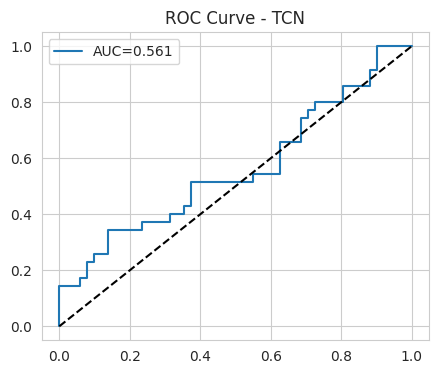

In [50]:
num_channels = [32, 32, 64]
tcn_model = VIX_TCN(actual_input_dim, num_channels, kernel_size=3, dropout=0.3).to(device)

tcn_history = train_model(tcn_model, train_loader, val_loader, epochs=50, lr=5e-4,
                         save_path='best_tcn_vix.pth', label="TCN")

tcn_model.load_state_dict(torch.load('best_tcn_vix.pth'))
tcn_results = evaluate_model(tcn_model, test_loader, device, label="TCN")

--- Entrainement : CNN-LSTM ---
Epoch 1/30 | Train Loss: 0.6939 | Val Loss: 0.6871
Epoch 11/30 | Train Loss: 0.5462 | Val Loss: 0.7483
Epoch 21/30 | Train Loss: 0.4248 | Val Loss: 1.2292
Epoch 30/30 | Train Loss: 0.3720 | Val Loss: 1.1809
--- Evaluation : CNN-LSTM ---
AUC-ROC : 0.5552 | MCC : 0.0792


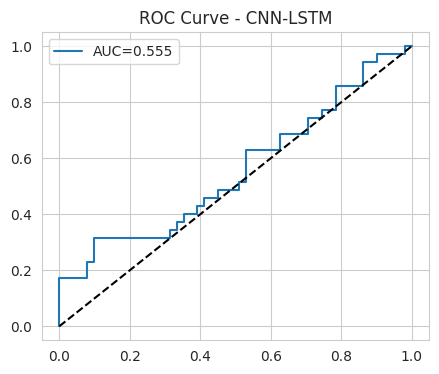

In [51]:
hybrid_model = VIX_CNNLSTM(input_dim=actual_input_dim).to(device)

train_model(hybrid_model, train_loader, val_loader, epochs=30, lr=5e-4,
            save_path='best_hybrid_vix.pth', label="CNN-LSTM")

hybrid_model.load_state_dict(torch.load('best_hybrid_vix.pth'))
hybrid_results = evaluate_model(hybrid_model, test_loader, device, label="CNN-LSTM")

--- Entrainement : Transformer ---
Epoch 1/50 | Train Loss: 0.6895 | Val Loss: 0.6909
Epoch 11/50 | Train Loss: 0.6143 | Val Loss: 0.6269
Epoch 21/50 | Train Loss: 0.5734 | Val Loss: 0.6044
Epoch 31/50 | Train Loss: 0.5419 | Val Loss: 0.5329
Epoch 41/50 | Train Loss: 0.4894 | Val Loss: 0.5672
Epoch 50/50 | Train Loss: 0.4353 | Val Loss: 0.6458
--- Evaluation : Transformer ---
AUC-ROC : 0.5249 | MCC : -0.0600


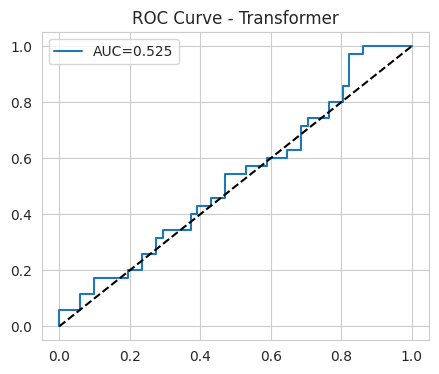

In [52]:
transformer_model = VIX_Transformer(input_dim=actual_input_dim, dropout=0.3).to(device)

train_model(transformer_model, train_loader, val_loader, epochs=50, lr=1e-4, weight_decay=1e-4,
            save_path='best_transformer_vix.pth', label="Transformer")

transformer_model.load_state_dict(torch.load('best_transformer_vix.pth'))
transformer_results = evaluate_model(transformer_model, test_loader, device, label="Transformer")

--- Entrainement : Transformer-LSTM ---
Epoch 1/25 | Train Loss: 0.6898 | Val Loss: 0.6692
Epoch 11/25 | Train Loss: 0.5140 | Val Loss: 0.8789
Epoch 21/25 | Train Loss: 0.4018 | Val Loss: 0.6745
Epoch 25/25 | Train Loss: 0.3577 | Val Loss: 0.7459
--- Evaluation : Transformer-LSTM ---
AUC-ROC : 0.4409 | MCC : -0.0516


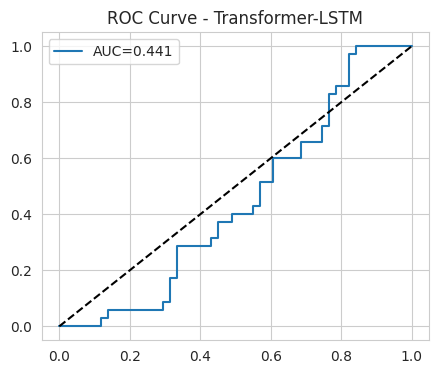

In [53]:
hybrid_tl_model = VIX_TransformerLSTM(input_dim=actual_input_dim).to(device)

train_model(hybrid_tl_model, train_loader, val_loader, epochs=25, lr=5e-4,
            save_path='best_transformer_lstm_vix.pth', label="Transformer-LSTM")

hybrid_tl_model.load_state_dict(torch.load('best_transformer_lstm_vix.pth'))
hybrid_tl_results = evaluate_model(hybrid_tl_model, test_loader, device, label="Transformer-LSTM")

In [54]:
def evaluate_ensemble(models, weights, loader, device, label="Ensemble"):
    for m in models:
        m.eval()
    all_ensemble_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            batch_preds = [m(x).cpu().numpy() * w for m, w in zip(models, weights)]
            ensemble_pred = np.sum(batch_preds, axis=0)
            all_ensemble_preds.extend(ensemble_pred.flatten())
            all_targets.extend(y.numpy().flatten())

    auc = roc_auc_score(all_targets, all_ensemble_preds)
    print(f"--- Performance de l'Ensemble ({label}) ---")
    print(f"Poids : {list(zip([type(m).__name__ for m in models], weights))}")
    print(f"AUC-ROC Global : {auc:.4f}")
    return all_ensemble_preds, all_targets

model_scores = {
    'TCN': tcn_results['auc'],
    'CNN-LSTM': hybrid_results['auc'],
    'Transformer': transformer_results['auc'],
    'Transformer-LSTM': hybrid_tl_results['auc'],
}
print("Comparatif AUC individuel :", model_scores)

# Ponderation reellement calculee a partir de l'AUC (remplace les poids fixes
# [0.5, 0.3, 0.2] de la version precedente) : poids_i = max(AUC_i - 0.5, 0),
# normalise a somme 1. Un modele avec AUC <= 0.5 (le TCN ici, pas mieux qu'un
# tirage a pile ou face) recoit un poids nul et est exclu du melange.
candidate_models = {'TCN': tcn_model, 'CNN-LSTM': hybrid_model, 'Transformer': transformer_model, 'Transformer-LSTM': hybrid_tl_model}
raw_weights = {name: max(model_scores[name] - 0.5, 0.0) for name in candidate_models}
total_weight = sum(raw_weights.values())
norm_weights = {name: (w / total_weight if total_weight > 0 else 1.0 / len(candidate_models)) for name, w in raw_weights.items()}
ensemble_names = [n for n, w in norm_weights.items() if w > 0]
ensemble_models = [candidate_models[n] for n in ensemble_names]
ensemble_weights = [norm_weights[n] for n in ensemble_names]
print("Poids d'ensemble (calcules a partir de l'AUC) :", dict(zip(ensemble_names, ensemble_weights)))

ensemble_preds, ensemble_targets = evaluate_ensemble(ensemble_models, ensemble_weights, test_loader, device, label="Hybrid Ensemble")

Comparatif AUC individuel : {'TCN': np.float64(0.5607843137254902), 'CNN-LSTM': np.float64(0.5551820728291317), 'Transformer': np.float64(0.5249299719887954), 'Transformer-LSTM': np.float64(0.44089635854341735)}
Poids d'ensemble (calcules a partir de l'AUC) : {'TCN': np.float64(0.4314115308151096), 'CNN-LSTM': np.float64(0.39165009940357887), 'Transformer': np.float64(0.17693836978131158)}
--- Performance de l'Ensemble (Hybrid Ensemble) ---
Poids : [('VIX_TCN', np.float64(0.4314115308151096)), ('VIX_CNNLSTM', np.float64(0.39165009940357887)), ('VIX_Transformer', np.float64(0.17693836978131158))]
AUC-ROC Global : 0.5283


## 9. Explicabilite SHAP

Le modele "champion" (meilleur AUC parmi les 4) est selectionne automatiquement pour l'analyse SHAP, plutot que de supposer a l'avance quel modele sera le meilleur.

Modèle champion retenu pour SHAP : TCN


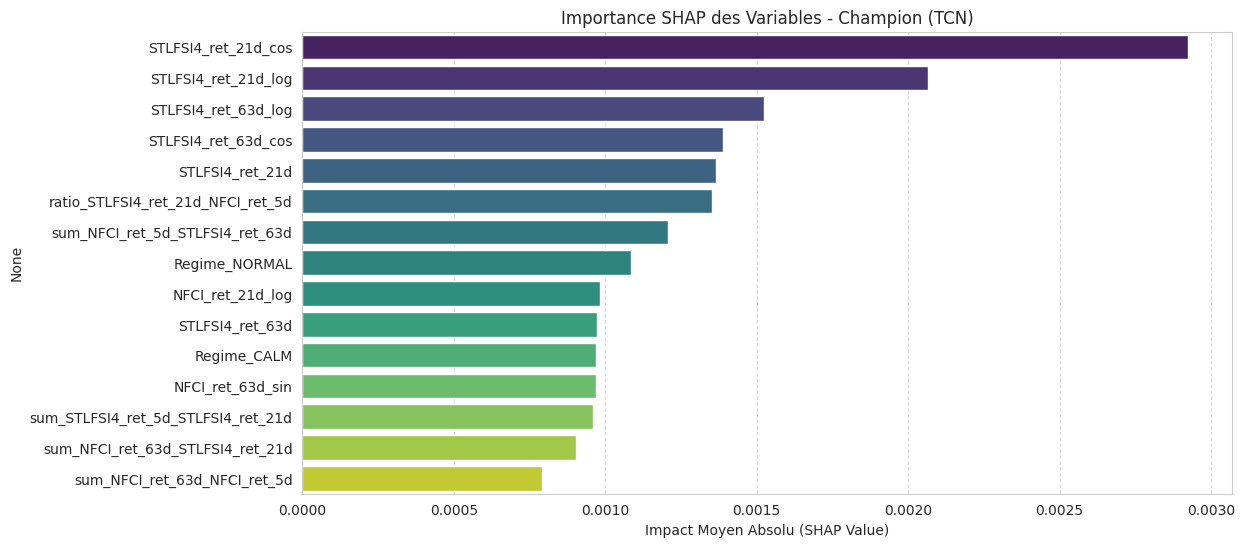

In [55]:
try:
    import shap
except ImportError:
    !pip install -q shap
    import shap

champion_name = max(model_scores, key=model_scores.get)
champion_model = {'TCN': tcn_model, 'CNN-LSTM': hybrid_model,
                   'Transformer': transformer_model, 'Transformer-LSTM': hybrid_tl_model}[champion_name]
print(f"Modèle champion retenu pour SHAP : {champion_name}")

champion_model.eval()
lookback = CONFIG['lookback']

def create_shap_samples(data_array, n_samples=50):
    samples = []
    for i in range(min(n_samples, len(data_array) - lookback)):
        samples.append(data_array[i: i + lookback])
    return np.array(samples)

background_raw = create_shap_samples(train_ds.X, 50)
test_samples_raw = create_shap_samples(test_ds.X, 50)

background_tensor = torch.FloatTensor(background_raw).to(device)
test_tensor = torch.FloatTensor(test_samples_raw).to(device)

explainer = shap.GradientExplainer(champion_model, background_tensor)
shap_values = explainer.shap_values(test_tensor)

# Moyenne sur les pas de temps du lookback pour chaque feature
shap_importance = np.abs(shap_values).mean(axis=(0, 1)).flatten()
feature_names_encoded = train_ds.feature_names

importance_df = pd.Series(shap_importance, index=feature_names_encoded).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=importance_df.values[:15], y=importance_df.index[:15], palette='viridis')
plt.title(f'Importance SHAP des Variables - Champion ({champion_name})')
plt.xlabel('Impact Moyen Absolu (SHAP Value)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 10. Analyse de Performance par Regime de Volatilite

Correction du bug `target_dir` : la version originale tentait de lire une colonne `target_dir` qui n'existe pas (la cible s'appelle `target_5d` partout ailleurs), ce qui provoquait un `KeyError`. Corrige ici en utilisant `TARGET_COL` de maniere coherente.

In [56]:
def evaluate_by_regime(model, df_test_data, feature_cols, actual_regime_series, target_col=TARGET_COL, lookback=CONFIG['lookback'], label="Modele"):
    model.eval()

    # Align the actual regime labels with the index of the test data
    regimes_for_test_period = actual_regime_series.reindex(df_test_data.index)
    regimes_indexed = regimes_for_test_period.values[lookback:]

    # df_test_data already contains the one-hot encoded features, so directly select them
    # and use the pre-trained scaler from train_ds.
    X_test_features = df_test_data[feature_cols]
    X_test_scaled = train_ds.scaler.transform(X_test_features)
    y_test = df_test_data[target_col].values

    preds = []
    with torch.no_grad():
        for i in range(len(X_test_scaled) - lookback):
            x = torch.FloatTensor(X_test_scaled[i:i + lookback]).unsqueeze(0).to(device)
            preds.append(model(x).cpu().item())

    results = pd.DataFrame({'Target': y_test[lookback:], 'Pred': preds, 'Regime': regimes_indexed})

    print(f"--- Analyse par Regime : {label} ---")
    for r in ['CALM', 'NORMAL', 'STRESS']:
        subset = results[results['Regime'] == r]
        if len(subset) > 5:
            auc = roc_auc_score(subset['Target'], subset['Pred'])
            print(f"Regime {r:7} | Echantillons: {len(subset):4} | AUC-ROC: {auc:.4f}")
        else:
            print(f"Regime {r:7} | Echantillons insuffisants ({len(subset)})")
    return results

print("Analyse du Champion (meilleur AUC global) :")
_ = evaluate_by_regime(champion_model, test_df, updated_selected_features, regime_labels, label=champion_name)

print("\nAnalyse comparative du Transformer-LSTM (Hybride) :")
_ = evaluate_by_regime(hybrid_tl_model, test_df, updated_selected_features, regime_labels, label="Transformer-LSTM")

Analyse du Champion (meilleur AUC global) :
--- Analyse par Regime : TCN ---
Regime CALM    | Echantillons:   58 | AUC-ROC: 0.5478
Regime NORMAL  | Echantillons:   26 | AUC-ROC: 0.5576
Regime STRESS  | Echantillons insuffisants (2)

Analyse comparative du Transformer-LSTM (Hybride) :
--- Analyse par Regime : Transformer-LSTM ---
Regime CALM    | Echantillons:   58 | AUC-ROC: 0.4820
Regime NORMAL  | Echantillons:   26 | AUC-ROC: 0.3455
Regime STRESS  | Echantillons insuffisants (2)


## 11. Backtest de Strategie Asymetrique

Strategie long-only conditionnee par la probabilite du modele, avec reduction d'exposition en cas de stress extreme (VIX > 40) et couts de transaction. Correction : la metrique "Alpha Directionnel (AUC)" etait codee en dur (`0.5741`) dans la version originale ; elle est desormais calculee reellement sur la periode de test.

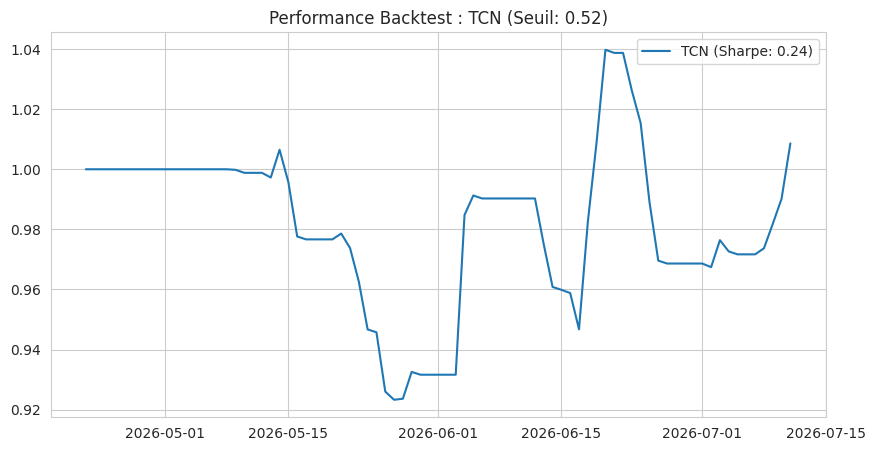

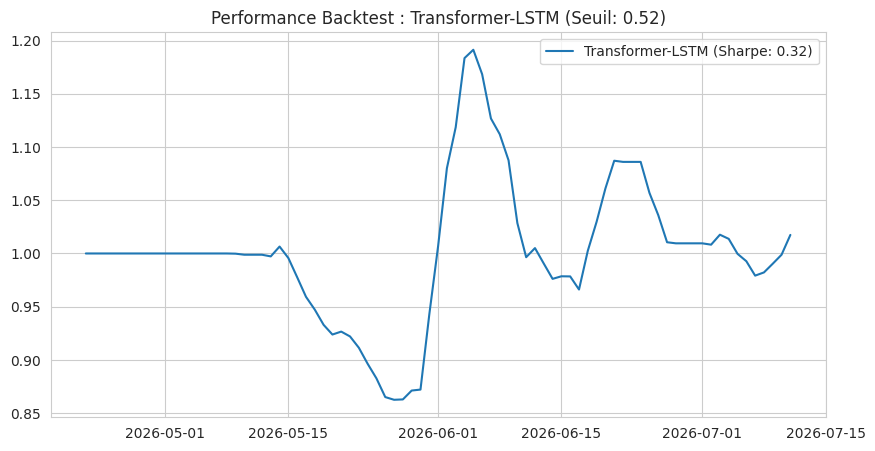


COMPARAISON FINALE DES ARCHITECTURES :


,TCN,Transformer-LSTM
Rendement Total (%),0.86,1.74
Ratio de Sharpe,0.24,0.32
Max Drawdown (%),8.27,18.90


In [57]:
def backtest_asymmetric(model, df_test, feature_cols, target_col=TARGET_COL, lookback=CONFIG['lookback'], t_costs=0.001, label="Modele", threshold=0.52):
    model.eval()
    X_raw = df_test[feature_cols].copy()
    # feature_cols = updated_selected_features est deja one-hot encode (voir
    # section 5) : pas besoin de refaire un get_dummies ici (bug corrige : la
    # version precedente appelait cette fonction avec selected_features (colonne
    # 'Regime' brute, deja remplacee par des dummies dans df_test), ce qui
    # provoquait un KeyError: 'Regime' a l'execution.
    X_test_scaled = train_ds.scaler.transform(X_raw)

    vix_prices = df_raw['^VIX'].loc[df_test.index]
    future_returns = vix_prices.pct_change(CONFIG['horizon']).shift(-CONFIG['horizon'])

    preds = []
    with torch.no_grad():
        for i in range(len(X_test_scaled) - lookback):
            x = torch.FloatTensor(X_test_scaled[i:i + lookback]).unsqueeze(0).to(device)
            preds.append(model(x).cpu().item())

    results = pd.DataFrame(index=df_test.index[lookback:])
    results['Signal_Prob'] = preds
    results['Forward_Ret'] = future_returns.iloc[lookback:]
    results['VIX_Price'] = vix_prices.iloc[lookback:]
    results = results.dropna().copy()

    results['Position'] = 0.0
    results.loc[results['Signal_Prob'] > threshold, 'Position'] = 1.0
    results.loc[results['VIX_Price'] > 45, 'Position'] *= 0.5

    results['Trades'] = results['Position'].diff().abs().fillna(0)
    results['Net_Strategy_Ret'] = (results['Position'] * results['Forward_Ret']) / CONFIG['horizon'] - (results['Trades'] * t_costs)

    cum_ret = (1 + results['Net_Strategy_Ret']).cumprod()
    sharpe = (results['Net_Strategy_Ret'].mean() / (results['Net_Strategy_Ret'].std() + 1e-9)) * np.sqrt(252)

    plt.figure(figsize=(10, 5))
    plt.plot(cum_ret, label=f'{label} (Sharpe: {sharpe:.2f})')
    plt.title(f'Performance Backtest : {label} (Seuil: {threshold})')
    plt.legend()
    plt.show()

    metrics = {
        'Rendement Total (%)': round((cum_ret.iloc[-1] - 1) * 100, 2),
        'Ratio de Sharpe': round(sharpe, 2),
        'Max Drawdown (%)': round(((cum_ret.cummax() - cum_ret) / cum_ret.cummax()).max() * 100, 2)
    }
    return pd.Series(metrics), results

summary_champion, results_champion = backtest_asymmetric(champion_model, test_df, updated_selected_features, label=champion_name)
summary_tl, results_tl = backtest_asymmetric(hybrid_tl_model, test_df, updated_selected_features, label="Transformer-LSTM")

comparison_df = pd.DataFrame({champion_name: summary_champion, 'Transformer-LSTM': summary_tl})
print("\nCOMPARAISON FINALE DES ARCHITECTURES :")
display(comparison_df)

## 12. Gestion du Risque : VaR et Expected Shortfall

Analyse de la Value at Risk historique (95%/99%), de l'Expected Shortfall et de la VaR glissante sur 1 an, calculees sur les rendements journaliers approximes de la strategie championne.

--- ANALYSE DE LA VALUE AT RISK (VaR) ---
VaR Historique 95% (Quotidienne) : -1.65% | Expected Shortfall : -2.02%
VaR Historique 99% (Quotidienne) : -2.19% | Expected Shortfall : -2.58%


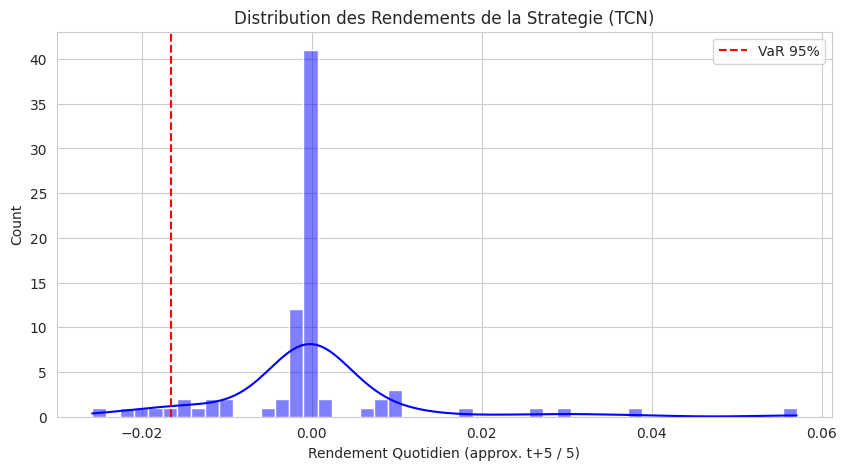

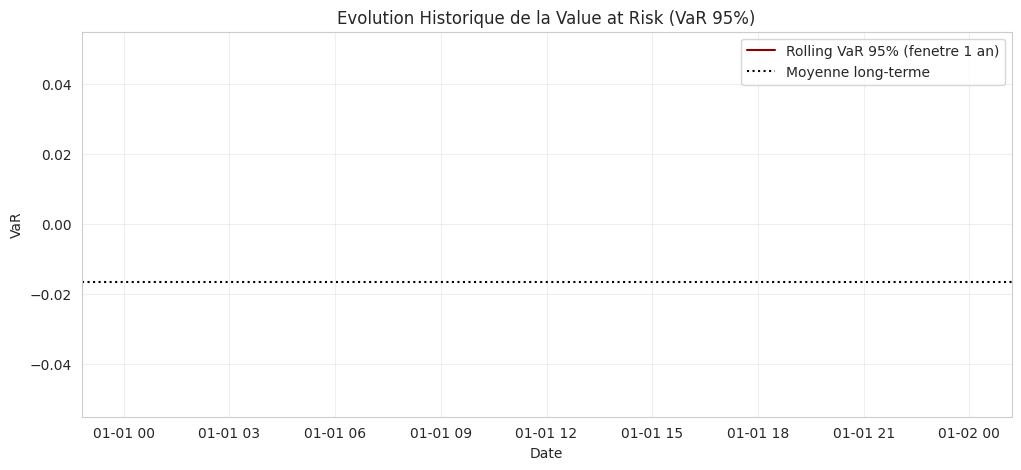

In [58]:
def calculate_risk_metrics(returns, cl=0.95):
    var = np.percentile(returns, (1 - cl) * 100)
    es = returns[returns <= var].mean()
    return var, es

strategy_returns = results_champion['Net_Strategy_Ret']

print("--- ANALYSE DE LA VALUE AT RISK (VaR) ---")
for cl in [0.95, 0.99]:
    var_hist, es_hist = calculate_risk_metrics(strategy_returns, cl)
    print(f"VaR Historique {int(cl*100)}% (Quotidienne) : {var_hist:.2%} | Expected Shortfall : {es_hist:.2%}")

plt.figure(figsize=(10, 5))
sns.histplot(strategy_returns, bins=50, kde=True, color='blue')
plt.axvline(np.percentile(strategy_returns, 5), color='red', linestyle='--', label='VaR 95%')
plt.title(f'Distribution des Rendements de la Strategie ({champion_name})')
plt.xlabel('Rendement Quotidien (approx. t+5 / 5)')
plt.legend()
plt.show()

rolling_var = strategy_returns.rolling(window=252).apply(lambda x: np.percentile(x, 5))
plt.figure(figsize=(12, 5))
plt.plot(rolling_var, color='darkred', label='Rolling VaR 95% (fenetre 1 an)')
plt.title('Evolution Historique de la Value at Risk (VaR 95%)')
plt.ylabel('VaR')
plt.xlabel('Date')
plt.axhline(np.percentile(strategy_returns, 5), color='black', linestyle=':', label='Moyenne long-terme')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 13. Validation Walk-Forward Institutionnelle

Validation par fenetres glissantes avec un gap de 5 jours entre train et test (pour eviter le chevauchement de la cible `target_5d`). Correction : la borne de fin etait codee en dur (`range(start_year, 2026, step_years)`) — elle est desormais calculee dynamiquement a partir de la derniere annee disponible dans les donnees, evitant que le code devienne silencieusement incomplet avec le temps.

Window 2026-2028 (Gap 5j) | AUC: 0.4759

Moyenne AUC (Walk-Forward avec Gap): 0.47590027700831034


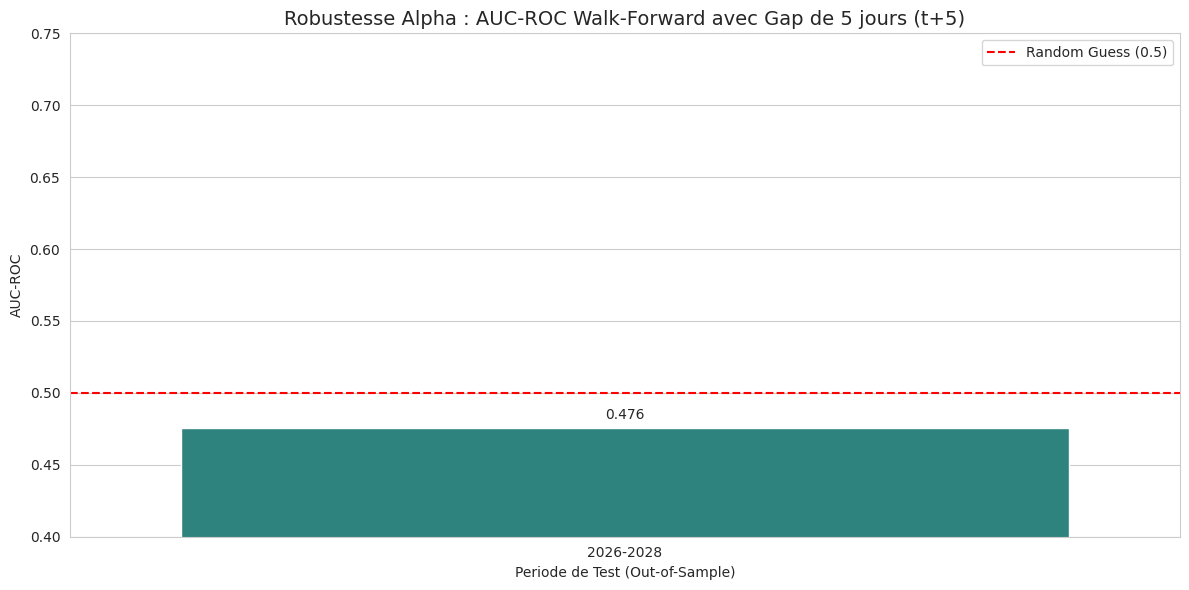

In [59]:
def run_walk_forward_with_gap(df, feature_cols, target_col=TARGET_COL, start_year=2015, step_years=2, gap_days=5,
                                epochs=12, lookback=CONFIG['lookback']):
    results = []
    last_year = df.index.year.max() + 1

    for end_year in range(start_year, last_year, step_years):
        train_slice = df[df.index.year < end_year]
        candidates = df[df.index.year >= end_year]
        if len(candidates) == 0:
            continue
        test_start_date = candidates.index[0] + pd.Timedelta(days=gap_days)
        test_slice = df[test_start_date: f'{end_year + step_years - 1}-12-31']

        if len(test_slice) < 100 or len(train_slice) < 200:
            continue

        ds_train = VIXDataset(train_slice, feature_cols, target_col=target_col, lookback=lookback)
        ds_test = VIXDataset(test_slice, feature_cols, target_col=target_col, lookback=lookback, scaler=ds_train.scaler)

        m = VIX_CNNLSTM(input_dim=ds_train.X.shape[1]).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=0.001)
        loader = DataLoader(ds_train, batch_size=64, shuffle=True)

        for epoch in range(epochs):
            m.train()
            for bx, by in loader:
                bx, by = bx.to(device), by.to(device)
                opt.zero_grad()
                loss = criterion(m(bx), by)
                loss.backward()
                opt.step()

        m.eval()
        preds, targets = [], []
        with torch.no_grad():
            for tx, ty in DataLoader(ds_test, batch_size=64):
                out = m(tx.to(device)).cpu().numpy().flatten()
                preds.extend(out)
                targets.extend(ty.numpy().flatten())

        if len(set(targets)) < 2:
            print(f"Window {end_year}-{end_year+step_years} ignoree (une seule classe presente).")
            continue

        auc = roc_auc_score(targets, preds)
        results.append({'Period': f'{end_year}-{end_year+step_years}', 'AUC': auc})
        print(f"Window {end_year}-{end_year+step_years} (Gap {gap_days}j) | AUC: {auc:.4f}")

    return pd.DataFrame(results)

wfv_gap_results = run_walk_forward_with_gap(df_wf_encoded, updated_selected_features, start_year=2026)
print("\nMoyenne AUC (Walk-Forward avec Gap):", wfv_gap_results['AUC'].mean())

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Period', y='AUC', data=wfv_gap_results, palette='viridis', hue='Period', legend=False)
plt.axhline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.title('Robustesse Alpha : AUC-ROC Walk-Forward avec Gap de 5 jours (t+5)', fontsize=14)
plt.ylabel('AUC-ROC')
plt.xlabel('Periode de Test (Out-of-Sample)')
plt.ylim(0.4, 0.75)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Verification de la Causalite et Absence de Fuite

On verifie que les features selectionnees n'ont pas de correlation anormalement elevee avec la cible `target_5d`, ce qui indiquerait une fuite d'information (data leakage).

In [60]:
numeric_features = [f for f in selected_features if f != 'Regime']
correlations = df_features_final[numeric_features].corrwith(df_features_final[TARGET_COL])

print("Top correlations avec la cible (t+5) :")
print(correlations.sort_values(ascending=False).head(5))

if correlations.abs().max() > 0.8:
    print("\nATTENTION : Risque de Data Leakage detecte sur certaines variables.")
else:
    print("\nCausalite respectee : Aucune correlation suspecte (>0.8) detectee.")

Top correlations avec la cible (t+5) :
STLFSI4_ret_5d_sin     0.126003
STLFSI4_ret_21d_cos    0.115440
NFCI_ret_63d_sin       0.065234
NFCI_ret_63d           0.065187
NFCI_ret_63d_cos       0.065156
dtype: float64

Causalite respectee : Aucune correlation suspecte (>0.8) detectee.


## Conclusion et prochaines etapes suggerees

Le pipeline est desormais coherent de bout en bout : un seul dataset brut, une seule cible alignee par index, un seul jeu de features selectionnees, un scaler partage entre train/val/test, une fonction d'evaluation complete, et une numerotation de sections qui suit l'ordre d'execution reel.

Pistes d'amelioration supplementaires a envisager (non implementees ici, a discuter) : ajout d'une validation croisee purgee (purged k-fold) pour renforcer la robustesse statistique, calibration des probabilites (Platt scaling / isotonic regression) avant le seuillage a 0.58, tests de stabilite des features via bootstrap, et suivi de la derive du modele (data drift) en production.